
--- FINAL COMPARISON TABLE ---
Node  Random Walk Score  Inbuilt PageRank
   A            0.32473           0.32503
   D            0.26120           0.26105
   B            0.21137           0.21578
   C            0.17340           0.16814
   E            0.02930           0.03000


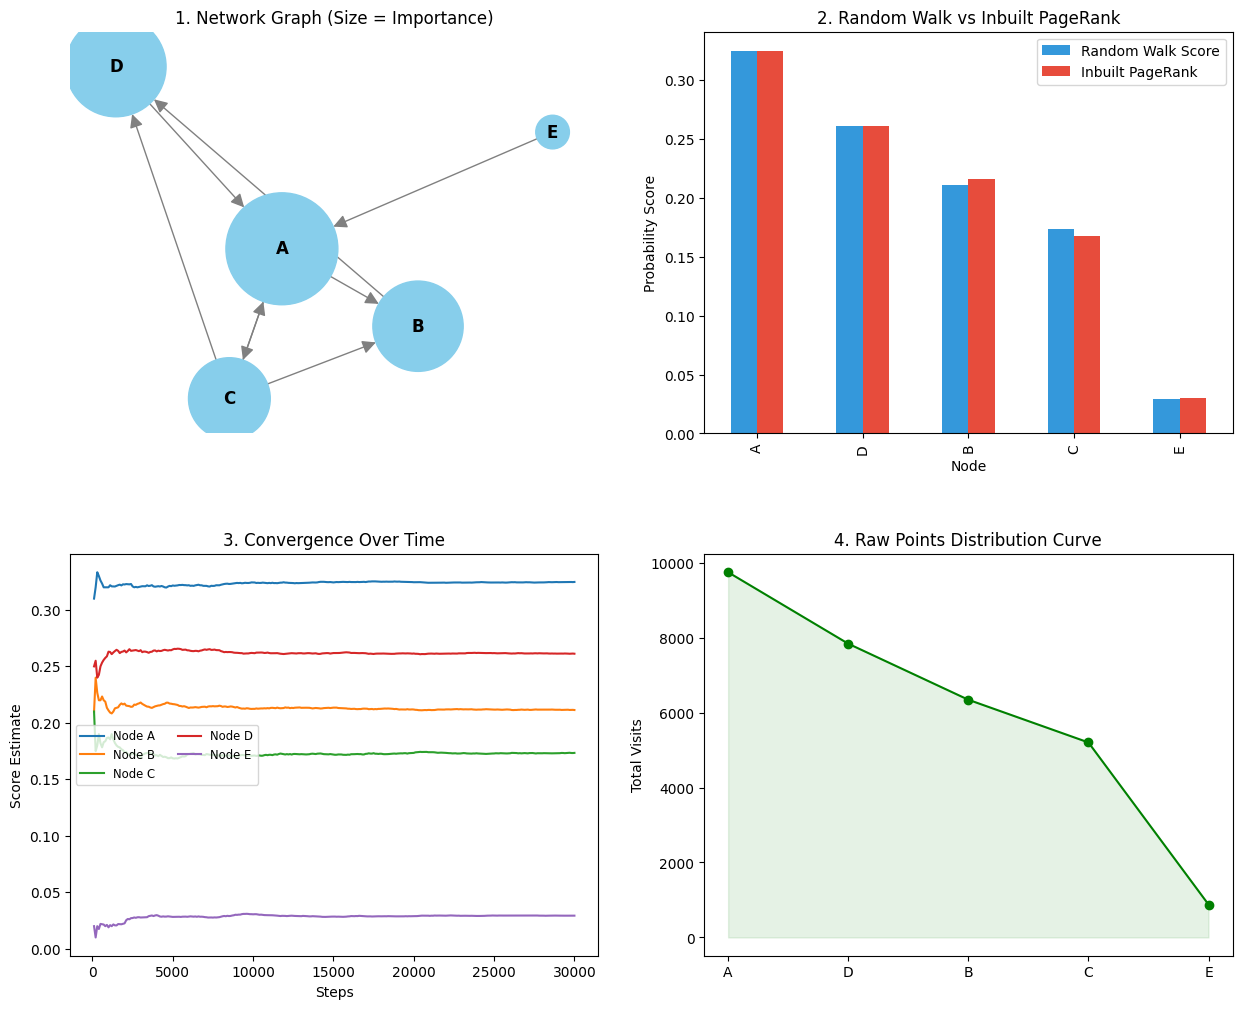

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd

# Set seed for consistency in classroom demonstrations
random.seed(42)

# =================================================================
# STEP 1: Create/take a directed graph.
# =================================================================
def create_graph():
    G = nx.DiGraph()
    # A network where A and D are the main 'hubs'
    edges = [('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'A'),
             ('C', 'B'), ('C', 'D'), ('D', 'A'), ('E', 'A')]
    G.add_edges_from(edges)
    return G

# =================================================================
# STEP 2: Perform a random walk.
# =================================================================
def perform_random_walk(G, num_steps=30000, damping_factor=0.85):
    nodes = list(G.nodes())
    points = {node: 0 for node in nodes}
    history = {node: [] for node in nodes}

    current_node = random.choice(nodes)

    for i in range(1, num_steps + 1):
        points[current_node] += 1

        # Capture current score for convergence visualization
        if i % 100 == 0:
            for node in nodes:
                history[node].append(points[node] / i)

        # Probabilistic movement (Damping Factor)
        if random.random() < damping_factor:
            neighbors = list(G.successors(current_node))
            current_node = random.choice(neighbors) if neighbors else random.choice(nodes)
        else:
            current_node = random.choice(nodes)

    return points, history

# =================================================================
# STEP 3 & 4: Comparison Table & Results
# =================================================================
def process_results(G, points, num_steps, damping_factor=0.85):
    inbuilt_pr = nx.pagerank(G, alpha=damping_factor)
    rw_scores = {node: p / num_steps for node, p in points.items()}

    # Create Table
    comparison_data = []
    for node in sorted(G.nodes()):
        comparison_data.append({
            'Node': node,
            'Random Walk Score': round(rw_scores[node], 5),
            'Inbuilt PageRank': round(inbuilt_pr[node], 5)
        })
    df = pd.DataFrame(comparison_data).sort_values(by='Inbuilt PageRank', ascending=False)

    print("\n--- FINAL COMPARISON TABLE ---")
    print(df.to_string(index=False))
    return df, rw_scores, inbuilt_pr

# =================================================================
# VISUALIZATIONS (The 4 Pillars)
# =================================================================
def plot_all(G, df, history, rw_scores, num_steps):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3)

    # 1. Directed Graph Visualization (Node size = Random Walk Score)
    ax1 = axes[0, 0]
    pos = nx.spring_layout(G, seed=42)
    node_sizes = [rw_scores[node] * 20000 for node in G.nodes()] # Scaled for visibility
    nx.draw(G, pos, ax=ax1, with_labels=True, node_size=node_sizes,
            node_color='skyblue', arrowsize=20, font_weight='bold', edge_color='gray')
    ax1.set_title("1. Network Graph (Size = Importance)")

    # 2. Comparison Bar Chart
    ax2 = axes[0, 1]
    df.set_index('Node').plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c'])
    ax2.set_title("2. Random Walk vs Inbuilt PageRank")
    ax2.set_ylabel("Probability Score")

    # 3. Convergence Plot
    ax3 = axes[1, 0]
    checkpoints = list(range(100, num_steps + 1, 100))
    for node in G.nodes():
        ax3.plot(checkpoints, history[node], label=f'Node {node}')
    ax3.set_title("3. Convergence Over Time")
    ax3.set_xlabel("Steps")
    ax3.set_ylabel("Score Estimate")
    ax3.legend(fontsize='small', ncol=2)

    # 4. Points Accumulation Curve (Distribution)
    ax4 = axes[1, 1]
    nodes_sorted = df['Node'].tolist()
    points_sorted = [rw_scores[n] * num_steps for n in nodes_sorted]
    ax4.plot(nodes_sorted, points_sorted, marker='o', linestyle='-', color='green')
    ax4.fill_between(nodes_sorted, points_sorted, color='green', alpha=0.1)
    ax4.set_title("4. Raw Points Distribution Curve")
    ax4.set_ylabel("Total Visits")

    plt.show()

# Run Sequence
num_steps = 30000
G = create_graph()
points, history = perform_random_walk(G, num_steps)
df_results, rw_scores_dict, _ = process_results(G, points, num_steps)
plot_all(G, df_results, history, rw_scores_dict, num_steps)